<div style="
  background: linear-gradient(145deg, #1a0b08, #2d1310);
  border: 4px solid transparent;
  border-radius: 14px;
  padding: 18px 22px;
  margin: 12px 0;
  font-size: 26px;
  font-weight: 600;
  color: #fff8f6;
  box-shadow: 0 6px 14px rgba(0,0,0,0.3);
  background-clip: padding-box;
  position: relative;
">
  <div style="
    position: absolute;
    inset: 0;
    padding: 4px;
    border-radius: 14px;
    background: linear-gradient(90deg, #ff7b00, #ff0054, #9d0208);
    -webkit-mask: 
      linear-gradient(#fff 0 0) content-box, 
      linear-gradient(#fff 0 0);
    -webkit-mask-composite: xor;
    mask-composite: exclude;
    pointer-events: none;
  "></div>
  
  <b>Recurrent Neural Networks: From Scratch, TensorFlow & PyTorch</b>
  <br>
  <span style="color:#ffb5a7; font-size: 18px;">(Comprehensive Comparative Implementations: NumPy Forward/BPTT, TF/Keras, and PyTorch)</span>
</div>


---

# Table of Contents 

1. [Task 1: Mathematical Foundations of Recurrent Neural Networks](#task-1)
2. [Task 2: Building a Simple RNN From Scratch in NumPy](#task-2)
   - 2.1 [Forward Propagation Through Time (Step-by-Step)](#task-2-1)
   - 2.2 [Backpropagation Through Time (BPTT) Derivation](#task-2-2)
   - 2.3 [Training the Scratch Model & Visualization](#task-2-3)
3. [Task 3: Implementing Simple RNN with TensorFlow & Keras](#task-3)
   - 3.1 [Sequential Model Architecture & Training](#task-3-1)
   - 3.2 [TF/Keras Forecast Visualization](#task-3-2)
4. [Task 4: Implementing Simple RNN with PyTorch](#task-4)
   - 4.1 [PyTorch nn.RNN Module & Training Loop](#task-4-1)
   - 4.2 [PyTorch Sequence Evaluation](#task-4-2)
5. [Task 5: Comparative Evaluation & Convergence Analysis](#task-5)
   - 5.1 [Three-Way Model Forecast Overlay](#task-5-1)
6. [Task 6: Interactive Quiz, Missing Code & Recurrence Puzzle](#task-6)
   - 6.1 [Missing Code Challenge: Implement Hidden State Update](#task-6-1)
   - 6.2 [Interactive Architecture Quiz](#task-6-2)
   - 6.3 [Interactive Sequence Continuation Puzzle](#task-6-3)

---


<a id="task-1"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">Task 1: Mathematical Foundations of Recurrent Neural Networks</span>


A **Recurrent Neural Network (RNN)** processes sequential data by maintaining an internal memory (hidden state $h_t$) that is updated at every time step $t$.

### Governing Equations:
1. **Hidden State Update:**
   $$h_t = \tanh(W_{xh} x_t + W_{hh} h_{t-1} + b_h)$$
   - $x_t \in \mathbb{R}^{d}$: Input vector at time step $t$.
   - $h_{t-1} \in \mathbb{R}^{m}$: Hidden state vector from previous time step $t-1$.
   - $W_{xh} \in \mathbb{R}^{m \times d}$: Input-to-hidden weight matrix.
   - $W_{hh} \in \mathbb{R}^{m \times m}$: Hidden-to-hidden recurrent transition matrix.
   - $b_h \in \mathbb{R}^{m}$: Hidden bias vector.
   - $\tanh$: Non-linear activation function mapping values into $(-1, 1)$.

2. **Output Prediction:**
   $$y_t = W_{hy} h_t + b_y$$
   - $W_{hy} \in \mathbb{R}^{k \times m}$: Hidden-to-output projection matrix.
   - $b_y \in \mathbb{R}^{k}$: Output bias vector.


In [1]:
# Core scientific and deep learning framework imports
import numpy as np
import matplotlib.pyplot as plt
import math

# Deep Learning Frameworks: PyTorch & TensorFlow
import torch
import torch.nn as nn
import torch.optim as optim

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Input

print('NumPy Version:     ', np.__version__)
print('PyTorch Version:   ', torch.__version__)
print('TensorFlow Version:', tf.__version__)

NumPy Version:      2.1.3
PyTorch Version:    2.11.0+cpu
TensorFlow Version: 2.20.0


<a id="task-2"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">Task 2: Building a Simple RNN From Scratch in NumPy</span>


<a id="task-2-1"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">2.1 Forward Propagation Through Time (Step-by-Step)</span>

Here we generate a continuous sinusoidal sequence and implement step-by-step vector matrix math.


In [ ]:
# Generate a continuous sine-wave sequence for our RNN benchmark
np.random.seed(42)
time_points = np.linspace(0, 50, 1000)
signal = np.sin(time_points)

# Prepare sequence pairs: sequence of length seq_len predicts the next step
seq_len = 20
X_list, y_list = [], []
for i in range(len(signal) - seq_len):
    X_list.append(signal[i:i+seq_len])
    y_list.append(signal[i+seq_len])

X_data = np.array(X_list)[:, :, np.newaxis] # Shape: (samples, seq_len, 1)
y_data = np.array(y_list)[:, np.newaxis]     # Shape: (samples, 1)

# Train-test split (80% train, 20% test)
split_idx = int(0.8 * len(X_data))
X_train, X_test = X_data[:split_idx], X_data[split_idx:]
y_train, y_test = y_data[:split_idx], y_data[split_idx:]

print(f'Dataset prepared: X_train shape = {X_train.shape}, y_train shape = {y_train.shape}')

Dataset prepared: X_train shape = (784, 20, 1), y_train shape = (784, 1)


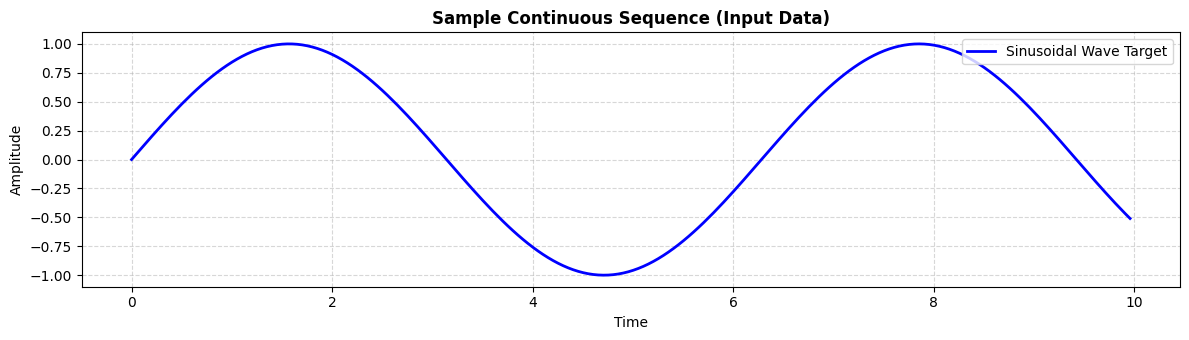

In [3]:
# Plot the raw sequence dataset using simple basic colors: 'blue'
plt.figure(figsize=(12, 3.5))
plt.plot(time_points[:200], signal[:200], color='blue', linewidth=2, label='Sinusoidal Wave Target')
plt.title('Sample Continuous Sequence (Input Data)', fontsize=12, fontweight='bold')
plt.xlabel('Time', fontsize=10)
plt.ylabel('Amplitude', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()


<a id="task-2-2"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">2.2 Backpropagation Through Time (BPTT) Derivation</span>

Definition of the NumPy RNN Cell class with forward pass and analytical backward gradients.


In [ ]:
class SimpleRNNScratch:
    def __init__(self, input_dim=1, hidden_dim=32, output_dim=1, learning_rate=0.01):
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.output_dim = output_dim
        self.lr = learning_rate
        
        # Xavier / Glorot parameter initialization
        self.W_xh = np.random.randn(hidden_dim, input_dim) * np.sqrt(2.0 / (input_dim + hidden_dim))
        self.W_hh = np.random.randn(hidden_dim, hidden_dim) * np.sqrt(2.0 / (hidden_dim + hidden_dim))
        self.b_h  = np.zeros((hidden_dim, 1))
        
        self.W_hy = np.random.randn(output_dim, hidden_dim) * np.sqrt(2.0 / (hidden_dim + output_dim))
        self.b_y  = np.zeros((output_dim, 1))
        
    def forward(self, x_seq):
        """
        x_seq: array of shape (T, input_dim) representing one sequence sample
        Returns: predictions, list of hidden states
        """
        T = len(x_seq)
        h_states = { -1: np.zeros((self.hidden_dim, 1)) }
        
        # Loop across all time-steps
        for t in range(T):
            x_t = x_seq[t].reshape(-1, 1)
            # Hidden state: h_t = tanh(W_xh * x_t + W_hh * h_{t-1} + b_h)
            h_states[t] = np.tanh(np.dot(self.W_xh, x_t) + np.dot(self.W_hh, h_states[t-1]) + self.b_h)
            
        # Output prediction at final time step: y_pred = W_hy * h_T + b_y
        y_pred = np.dot(self.W_hy, h_states[T-1]) + self.b_y
        return y_pred, h_states
        
    def backward_and_step(self, x_seq, y_true, y_pred, h_states):
        """Implements Backpropagation Through Time (BPTT) and gradient updates."""
        T = len(x_seq)
        # Loss derivative w.r.t final output: dL/dy = 2 * (y_pred - y_true)
        dy = 2.0 * (y_pred - y_true)
        
        # Gradients for output weights and bias
        dW_hy = np.dot(dy, h_states[T-1].T)
        db_y  = dy
        
        # Initialize recurrent gradients
        dW_xh = np.zeros_like(self.W_xh)
        dW_hh = np.zeros_like(self.W_hh)
        db_h  = np.zeros_like(self.b_h)
        
        # Backpropagate into final hidden state
        dh = np.dot(self.W_hy.T, dy)
        
        # Loop backwards through time: t = T-1, T-2, ..., 0
        for t in reversed(range(T)):
            dtanh = (1.0 - h_states[t] ** 2) * dh
            x_t = x_seq[t].reshape(-1, 1)
            
            dW_xh += np.dot(dtanh, x_t.T)
            dW_hh += np.dot(dtanh, h_states[t-1].T)
            db_h  += dtanh
            
            # Gradient passed to previous hidden state
            dh = np.dot(self.W_hh.T, dtanh)
            
        # Gradient clipping to mitigate exploding gradients
        for grad in [dW_xh, dW_hh, dW_hy, db_h, db_y]:
            np.clip(grad, -1.0, 1.0, out=grad)
            
        # Parameter update
        self.W_xh -= self.lr * dW_xh
        self.W_hh -= self.lr * dW_hh
        self.W_hy -= self.lr * dW_hy
        self.b_h  -= self.lr * db_h
        self.b_y  -= self.lr * db_y

print('SimpleRNNScratch class defined successfully!')

SimpleRNNScratch class defined successfully!


<a id="task-2-3"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">2.3 Training the Scratch Model & Visualization</span>

Train the scratch model and visualize its convergence.


In [ ]:
# Train SimpleRNNScratch on the training set
rnn_scratch = SimpleRNNScratch(input_dim=1, hidden_dim=32, output_dim=1, learning_rate=0.005)
epochs = 15
scratch_losses = []

print('Starting Scratch RNN Training (NumPy BPTT)...')
for epoch in range(1, epochs + 1):
    total_loss = 0.0
    # Shuffle training indices
    perm = np.random.permutation(len(X_train))
    for idx in perm:
        x_sample = X_train[idx]
        y_sample = y_train[idx]
        
        y_pred, h_states = rnn_scratch.forward(x_sample)
        loss = (y_pred[0, 0] - y_sample[0]) ** 2
        total_loss += loss
        
        rnn_scratch.backward_and_step(x_sample, y_sample, y_pred, h_states)
        
    mean_loss = total_loss / len(X_train)
    scratch_losses.append(mean_loss)
    if epoch % 3 == 0 or epoch == 1:
        print(f'Epoch {epoch:2d}/{epochs} - Mean Squared Error: {mean_loss:.5f}')

# Generate predictions on test set
scratch_preds = [rnn_scratch.forward(X_test[i])[0][0, 0] for i in range(len(X_test))]

Starting Scratch RNN Training (NumPy BPTT)...
Epoch  1/15 - Mean Squared Error: 0.01104
Epoch  3/15 - Mean Squared Error: 0.00039
Epoch  6/15 - Mean Squared Error: 0.00008
Epoch  9/15 - Mean Squared Error: 0.00003
Epoch 12/15 - Mean Squared Error: 0.00002
Epoch 15/15 - Mean Squared Error: 0.00001


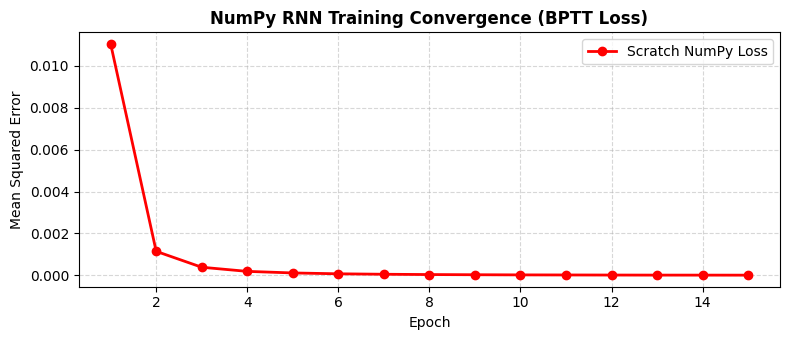

In [ ]:
# Plot Scratch RNN Training Loss curve using simple basic colors: 'red'
plt.figure(figsize=(8, 3.5))
plt.plot(range(1, epochs + 1), scratch_losses, color='red', linewidth=2, marker='o', label='Scratch NumPy Loss')
plt.title('NumPy RNN Training Convergence (BPTT Loss)', fontsize=12, fontweight='bold')
plt.xlabel('Epoch', fontsize=10)
plt.ylabel('Mean Squared Error', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

<a id="task-3"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">Task 3: Implementing Simple RNN with TensorFlow & Keras</span>


<a id="task-3-1"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">3.1 Sequential Model Architecture & Training</span>

Building and compiling an equivalent SimpleRNN in TensorFlow/Keras.


In [ ]:
# 3.1 TensorFlow / Keras SimpleRNN Architecture & Training
tf.random.set_seed(42)
tf_model = Sequential([
    Input(shape=(seq_len, 1)),
    SimpleRNN(32, activation='tanh'),
    Dense(1)
])
tf_model.compile(optimizer='adam', loss='mse')
tf_model.summary()

# Train model
tf_history = tf_model.fit(X_train, y_train, epochs=15, batch_size=32, validation_split=0.1, verbose=1)
tf_preds = tf_model.predict(X_test, verbose=0).flatten()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,121 (4.38 KB)

 Trainable params: 1,121 (4.38 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0782 - val_loss: 0.0149
Epoch 2/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0099 - val_loss: 0.0052
Epoch 3/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0033 - val_loss: 0.0021
Epoch 4/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0016 - val_loss: 0.0013
Epoch 5/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0010 - val_loss: 8.3747e-04
Epoch 6/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.7891e-04 - val_loss: 5.8830e-04
Epoch 7/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4.8790e-04 - val_loss: 4.4231e-04
Epoch 8/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.8240e-04 - val_loss: 3.5590e-04
Epoch 9/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.2371e-04 - val_loss: 3.0191e-04
Epoch 10/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.8656e-04 - val_loss: 2.6428e-04
Epoch 11/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.5744e-04 - val_loss: 2.3321e-04
Epoch 12/15
23/23 ━━━

<a id="task-3-2"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">3.2 TF/Keras Forecast Visualization</span>

Visualize Keras training and validation performance.


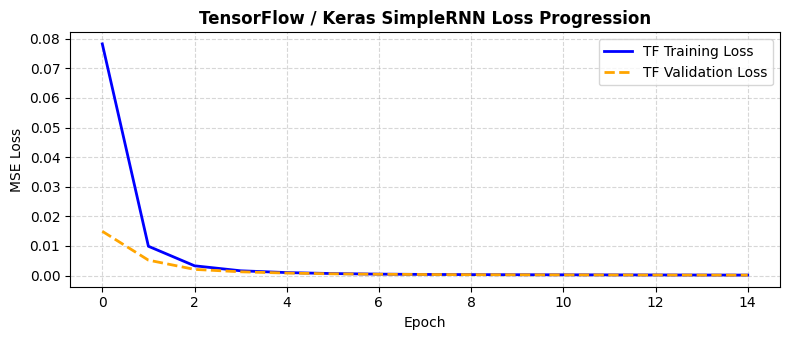

In [ ]:
# Plot TF/Keras Loss curve using simple basic colors: 'blue' (Train) and 'orange' (Val)
plt.figure(figsize=(8, 3.5))
plt.plot(tf_history.history['loss'], color='blue', linewidth=2, label='TF Training Loss')
plt.plot(tf_history.history['val_loss'], color='orange', linewidth=2, linestyle='--', label='TF Validation Loss')
plt.title('TensorFlow / Keras SimpleRNN Loss Progression', fontsize=12, fontweight='bold')
plt.xlabel('Epoch', fontsize=10)
plt.ylabel('MSE Loss', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

<a id="task-4"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">Task 4: Implementing Simple RNN with PyTorch</span>


<a id="task-4-1"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">4.1 PyTorch nn.RNN Module & Training Loop</span>

Defining modular PyTorch network and executing standard training loop.


In [ ]:
# 4.1 PyTorch nn.RNN Architecture & Explicit Training Loop
class PyTorchRNN(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, output_size=1):
        super(PyTorchRNN, self).__init__()
        self.hidden_size = hidden_size
        self.rnn = nn.RNN(input_size=input_size, hidden_size=hidden_size, batch_first=True)
        self.fc  = nn.Linear(hidden_size, output_size)
        
    def forward(self, x):
        # x shape: (batch_size, seq_len, input_size)
        out, h_n = self.rnn(x)
        # Take the output representation at the final sequence time step
        out = self.fc(out[:, -1, :])
        return out

# Convert NumPy datasets to PyTorch Tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
X_test_tensor  = torch.tensor(X_test, dtype=torch.float32)

torch.manual_seed(42)
torch_model = PyTorchRNN()
criterion = nn.MSELoss()
optimizer = optim.Adam(torch_model.parameters(), lr=0.005)

# Explicit PyTorch training loop
torch_losses = []
torch_epochs = 15
for epoch in range(1, torch_epochs + 1):
    torch_model.train()
    optimizer.zero_grad()
    predictions = torch_model(X_train_tensor)
    loss = criterion(predictions, y_train_tensor)
    loss.backward()
    optimizer.step()
    torch_losses.append(loss.item())
    if epoch % 3 == 0 or epoch == 1:
        print(f'PyTorch Epoch {epoch:2d}/{torch_epochs} - Loss: {loss.item():.5f}')
        
# Inference
torch_model.eval()
with torch.no_grad():
    torch_preds = torch_model(X_test_tensor).numpy().flatten()

PyTorch Epoch  1/15 - Loss: 0.68498
PyTorch Epoch  3/15 - Loss: 0.47828
PyTorch Epoch  6/15 - Loss: 0.27593
PyTorch Epoch  9/15 - Loss: 0.08443
PyTorch Epoch 12/15 - Loss: 0.08188
PyTorch Epoch 15/15 - Loss: 0.01927


<a id="task-4-2"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">4.2 PyTorch Sequence Evaluation</span>

Visualizing PyTorch training loss curve.


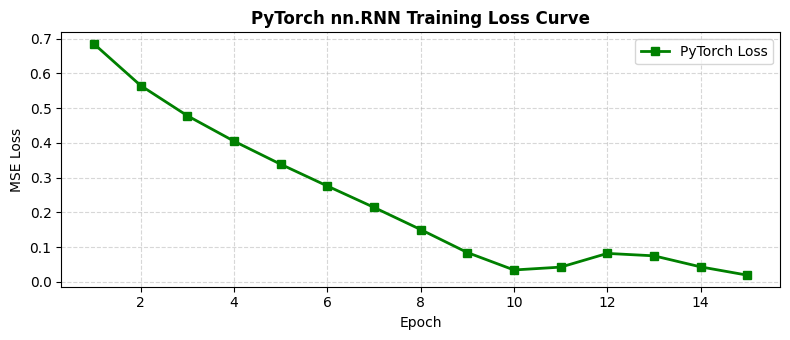

In [ ]:
# Plot PyTorch Loss curve using simple basic colors: 'green'
plt.figure(figsize=(8, 3.5))
plt.plot(range(1, len(torch_losses) + 1), torch_losses, color='green', linewidth=2, marker='s', label='PyTorch Loss')
plt.title('PyTorch nn.RNN Training Loss Curve', fontsize=12, fontweight='bold')
plt.xlabel('Epoch', fontsize=10)
plt.ylabel('MSE Loss', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

<a id="task-5"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">Task 5: Comparative Evaluation & Convergence Analysis</span>


<a id="task-5-1"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">5.1 Three-Way Model Forecast Overlay</span>

Direct visual comparison of Ground Truth against NumPy Scratch, TensorFlow, and PyTorch.


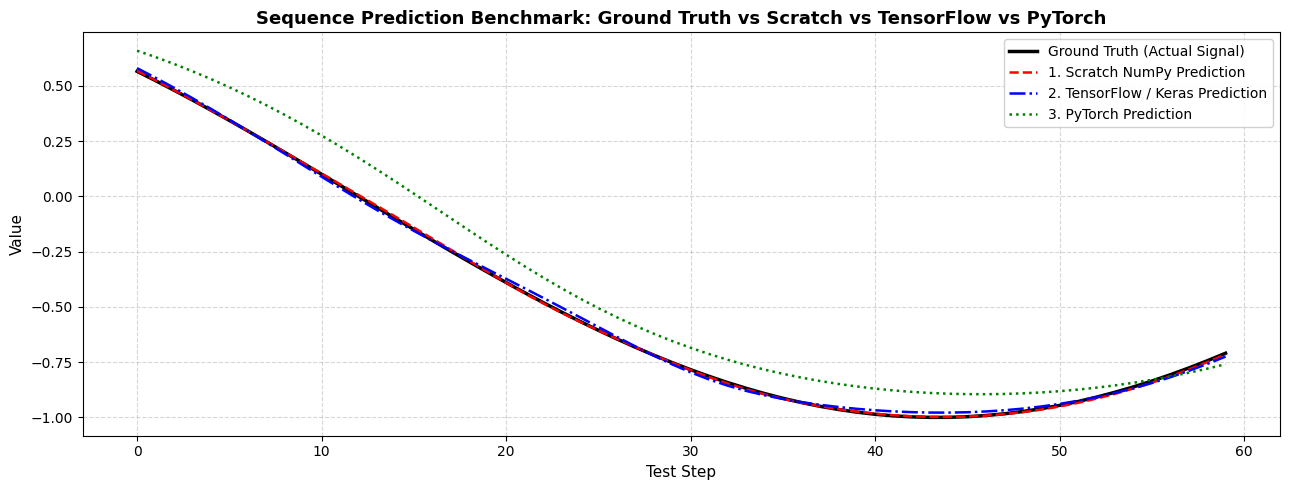

In [ ]:
# ====================================================================
# 3-Way Model Prediction Overlay Plot
# (Using simple basic colors: 'black', 'red', 'blue', 'green')
# ====================================================================
plot_window = 60
time_subset = np.arange(plot_window)

plt.figure(figsize=(13, 5))
plt.plot(time_subset, y_test[:plot_window], color='black', linewidth=2.5, label='Ground Truth (Actual Signal)')
plt.plot(time_subset, scratch_preds[:plot_window], color='red', linewidth=1.8, linestyle='--', label='1. Scratch NumPy Prediction')
plt.plot(time_subset, tf_preds[:plot_window], color='blue', linewidth=1.8, linestyle='-.', label='2. TensorFlow / Keras Prediction')
plt.plot(time_subset, torch_preds[:plot_window], color='green', linewidth=1.8, linestyle=':', label='3. PyTorch Prediction')

plt.title('Sequence Prediction Benchmark: Ground Truth vs Scratch vs TensorFlow vs PyTorch', fontsize=13, fontweight='bold')
plt.xlabel('Test Step', fontsize=11)
plt.ylabel('Value', fontsize=11)
plt.legend(loc='upper right', framealpha=0.9)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

<a id="task-6"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">Task 6: Interactive Quiz, Missing Code & Recurrence Puzzle</span>


<a id="task-6-1"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">6.1 Missing Code Challenge: Implement Hidden State Update</span>

Complete the missing arithmetic expression inside an RNN cell.


In [ ]:
# Exercise: Single-step forward calculation in pure NumPy
def rnn_step(x_t, h_prev, W_xh, W_hh, b_h):
    """Computes hidden state: h_t = tanh(W_xh @ x_t + W_hh @ h_prev + b_h)"""
    return np.tanh(np.dot(W_xh, x_t) + np.dot(W_hh, h_prev) + b_h)

# Verify with sample inputs
x_dummy = np.array([[0.5]])
h_dummy = np.zeros((4, 1))
Wxh_dummy = np.full((4, 1), 0.2)
Whh_dummy = np.eye(4) * 0.5
bh_dummy  = np.zeros((4, 1))

out = rnn_step(x_dummy, h_dummy, Wxh_dummy, Whh_dummy, bh_dummy)
print('Computed hidden state shape:', out.shape)
print('Values:\n', out)

Computed hidden state shape: (4, 1)
Values:
 [[0.09966799]
 [0.09966799]
 [0.09966799]
 [0.09966799]]


<a id="task-6-2"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">6.2 Interactive Architecture Quiz</span>

Test your conceptual understanding of recurrent networks.


### Concept Check: Recurrent Neural Network Foundations

**1. Why does a standard RNN suffer from the Vanishing Gradient problem during BPTT?**
- **A)** The learning rate automatically increases over time
- **B)** Repeated matrix multiplication by $W_{hh}$ and $\tanh'$ derivatives ($< 1$) causes gradients to decay exponentially as sequence length $T$ grows
- **C)** PyTorch and TensorFlow share the same memory cache
- **D)** $\tanh$ activation produces complex numbers

<details>
<summary><b>View Answer & Explanation</b></summary>

> **Correct Answer: B**  
> During Backpropagation Through Time (BPTT), the gradient of the loss with respect to early hidden states involves continuous product terms $\prod_{k} W_{hh}^T \text{diag}(1 - h_k^2)$. If the spectral radius of $W_{hh}$ is less than 1, the gradient exponentially shrinks to zero, preventing the network from learning long-term dependencies.
</details>

---

**2. What is the fundamental parameter-sharing property of RNNs?**
- **A)** An RNN reuses the exact same weight matrices ($W_{xh}$, $W_{hh}$, $W_{hy}$) across all temporal time steps
- **B)** Feedforward networks cannot use activation functions
- **C)** RNNs don't use backpropagation
- **D)** Weight matrices are randomly generated at each time step

<details>
<summary><b>View Answer & Explanation</b></summary>

> **Correct Answer: A**  
> Reusing the same weights at every time step allows the model to process sequences of arbitrary length and recognize patterns regardless of where they appear in time, all with a fixed parameter count.
</details>

---

**3. Why is Gradient Clipping commonly applied in recurrent models?**
- **A)** To prevent exploding gradients from destabilizing training when $\|\nabla\|$ becomes too large
- **B)** To speed up matrix multiplication
- **C)** To turn floating-point losses into integers
- **D)** To guarantee finding the global minimum

<details>
<summary><b>View Answer & Explanation</b></summary>

> **Correct Answer: A**  
> While vanishing gradients cause slow learning, exploding gradients can instantly push parameters to `NaN` or cause drastic jumps. Gradient clipping scales down the gradient vector whenever its norm exceeds a chosen threshold.
</details>


<a id="task-6-3"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">6.3 Interactive Sequence Continuation Puzzle</span>

Use the model to autonomously forecast a sequence step-by-step into the future.


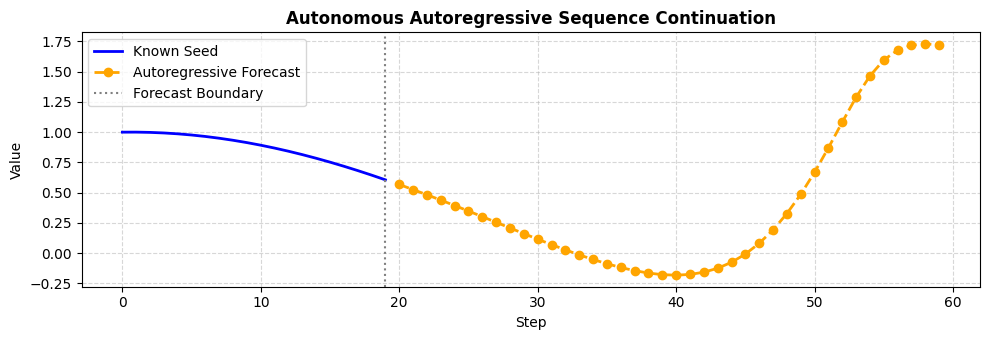

In [ ]:
# Autoregressive forecasting: Predicting multiple steps into the future
def forecast_future(model_obj, initial_seed, steps_ahead=30):
    history = list(initial_seed.flatten())
    predictions = []
    
    for _ in range(steps_ahead):
        x_in = np.array(history[-seq_len:]).reshape(seq_len, 1)
        y_next, _ = model_obj.forward(x_in)
        val = y_next[0, 0]
        predictions.append(val)
        history.append(val)
        
    return np.array(predictions)

# Forecast 40 steps ahead
seed = X_test[0]
forecast = forecast_future(rnn_scratch, seed, steps_ahead=40)

plt.figure(figsize=(10, 3.5))
plt.plot(range(len(seed)), seed.flatten(), color='blue', linewidth=2, label='Known Seed')
plt.plot(range(len(seed), len(seed) + len(forecast)), forecast, color='orange', linewidth=2, linestyle='--', marker='o', label='Autoregressive Forecast')
plt.axvline(x=len(seed) - 1, color='gray', linestyle=':', label='Forecast Boundary')
plt.title('Autonomous Autoregressive Sequence Continuation', fontsize=12, fontweight='bold')
plt.xlabel('Step', fontsize=10)
plt.ylabel('Value', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()